# PARTIE : MACHINE LEARNING

## Chargement des donnees :

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement:

df = pd.read_csv("players_clean1.csv", sep=",", encoding="utf-8-sig")
print(df.shape)

(1992, 32)


##  1. Préparation des données :

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


poste_cols = [c for c in df.columns if c.startswith("poste_")]
nat_cols = ["nat_Brazil", "nat_England", "nat_Spain", "nat_France", "nat_Argentina", "nat_Germany"]

features = ["age", "matches_played", "goals", "assists", "yellow_cards", "red_cards"] + poste_cols + nat_cols
target = "valeur_marchande_log"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (1593, 23) | Test : (399, 23)


## 2. Comparaison de plusieurs modèles de régression:

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modeles = {
    "Régression Linéaire": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Arbre de décision": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}
resultats = []
for nom, modele in modeles.items():
    modele.fit(X_train_scaled, y_train)
    y_pred = modele.predict(X_test_scaled)
    resultats.append({
        "Modèle": nom,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    })
resultats_df = pd.DataFrame(resultats).sort_values("R2", ascending=False)
resultats_df

,Modèle,MAE,RMSE,R2
0,Régression Linéaire,0.623157,0.806837,0.750526
3,Random Forest,0.635558,0.838472,0.730579
1,KNN,0.656992,0.867877,0.711350
2,Arbre de décision,0.711760,0.952973,0.651971


## 3.Validation croisée:

In [29]:
from sklearn.model_selection import cross_val_score

print("=== Validation croisée (5-fold, score R²) ===")
for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_train_scaled, y_train, cv=5, scoring="r2")
    print(f"{nom:25s} : R² moyen = {scores.mean():.3f} (+/- {scores.std():.3f})")

=== Validation croisée (5-fold, score R²) ===
Régression Linéaire       : R² moyen = 0.786 (+/- 0.019)
KNN                       : R² moyen = 0.740 (+/- 0.022)
Arbre de décision         : R² moyen = 0.722 (+/- 0.025)
Random Forest             : R² moyen = 0.766 (+/- 0.019)


## Optimisation des hyperparamètres (GridSearchCV) && Comparaison entre Régression Linéaire et Random Forest optimisé

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 6, 10, 15],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

rf_optimise = grid_search.best_estimator_
y_pred_rf_optimise = rf_optimise.predict(X_test_scaled)
r2_rf_optimise = r2_score(y_test, y_pred_rf_optimise)

print("Meilleurs paramètres (Random Forest) :", grid_search.best_params_)
print(f"R² Random Forest optimisé : {r2_rf_optimise:.3f}")
print(f"R² Régression Linéaire (référence) : {resultats_df.set_index('Modèle').loc['Régression Linéaire', 'R2']:.3f}")

Meilleurs paramètres (Random Forest) : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
R² Random Forest optimisé : 0.744
R² Régression Linéaire (référence) : 0.751


## Modele final (Régression Linéaire)

In [31]:
from sklearn.linear_model import LinearRegression

modele_final = LinearRegression()
modele_final.fit(X_train_scaled, y_train)

y_pred_final = modele_final.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.623
RMSE : 0.807
R²   : 0.751


## Préparer les données pour le clustering :

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cols_clustering = ["age", "matches_played", "goals", "assists", "valeur_marchande_log"]
X_cluster = StandardScaler().fit_transform(df[cols_clustering])

## Trouver le bon nombre de clusters (k):

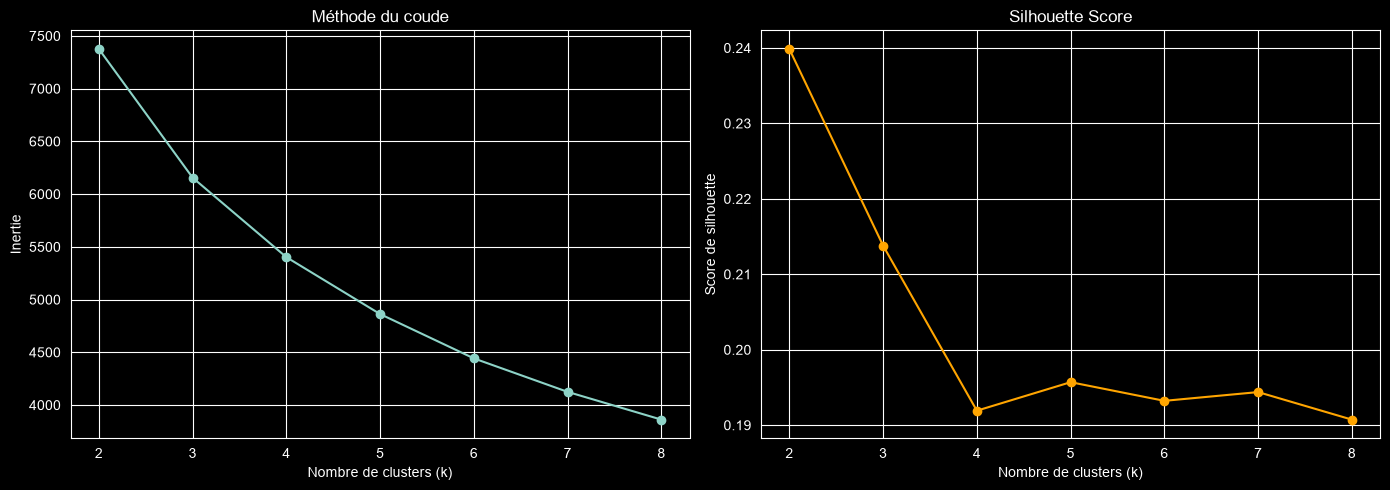

In [36]:
inertie = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertie.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertie, marker="o")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(k_range, silhouette_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Score de silhouette")

plt.tight_layout()
plt.savefig("choix_k_clustering.png", dpi=150)
plt.show()

## Clustering final avec k=3 :

In [54]:
k_optimal = 3

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_cluster)

score_final = silhouette_score(X_cluster, df["cluster"])
print(f"Silhouette Score final (k={k_optimal}) : {score_final:.3f}")

Silhouette Score final (k=3) : 0.214


##  Tableau d'interprétation des clusters :

In [55]:
profil_clusters = df.groupby("cluster")[cols_clustering].mean().round(2)
profil_clusters["nb_joueurs"] = df["cluster"].value_counts().sort_index()
profil_clusters

,age,matches_played,goals,assists,valeur_marchande_log,nb_joueurs
cluster,,,,,,
0,25.53,26.48,2.36,2.61,13.66,575
1,24.64,45.08,10.91,8.18,16.67,466
2,22.69,33.39,2.75,2.56,16.44,951


## Clusters_visualisation ( goals , valeur_marchande_eur):

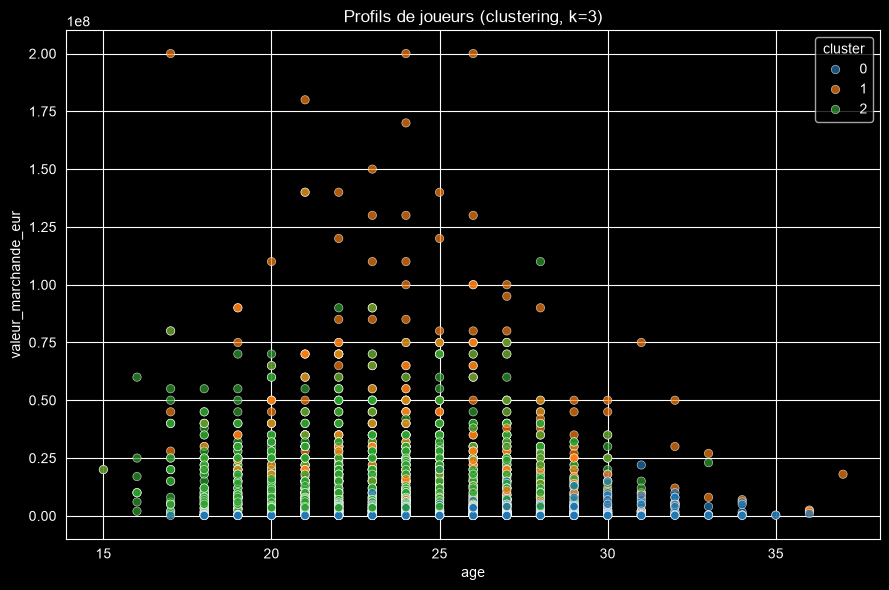

In [58]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="age", y="valeur_marchande_eur", hue="cluster", palette="tab10", alpha=0.7)
plt.title(f"Profils de joueurs (clustering, k={k_optimal})")
plt.tight_layout()
plt.savefig("clusters_visualisation.png", dpi=150)
plt.show()

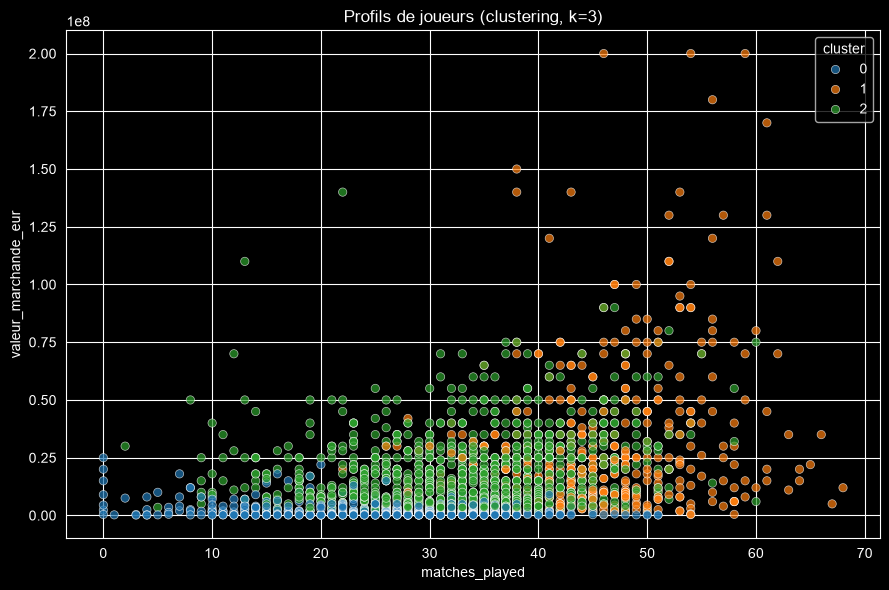

In [57]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="matches_played", y="valeur_marchande_eur", hue="cluster", palette="tab10", alpha=0.7)
plt.title(f"Profils de joueurs (clustering, k={k_optimal})")
plt.tight_layout()
plt.savefig("clusters_visualisation.png", dpi=150)
plt.show()

## Inférence :

## Effet de la nationalite :

In [32]:
nouveau_joueur = pd.DataFrame([{
    "age": 24,
    "matches_played": 35,
    "goals": 18,
    "assists": 10,
    "yellow_cards": 4,
    "red_cards": 0,
    **{c: 0 for c in poste_cols},
    **{c: 0 for c in nat_cols},
}])
nouveau_joueur["poste_Centre-Forward"] = 1
nouveau_joueur["nat_France"] = 1

nouveau_joueur = nouveau_joueur[features]
nouveau_joueur_scaled = scaler.transform(nouveau_joueur)

pred_log = modele_final.predict(nouveau_joueur_scaled)[0]
pred_eur = np.expm1(pred_log)

print(f"Valeur marchande prédite (log) : {pred_log:.2f}")
print(f"Valeur marchande prédite (€) : {pred_eur:,.0f} €")

Valeur marchande prédite (log) : 17.70
Valeur marchande prédite (€) : 48,734,466 €


In [34]:
nouveau_joueur = pd.DataFrame([{
    "age": 24,
    "matches_played": 35,
    "goals": 18,
    "assists": 10,
    "yellow_cards": 4,
    "red_cards": 0,
    **{c: 0 for c in poste_cols},
    **{c: 0 for c in nat_cols},
}])
nouveau_joueur["poste_Centre-Forward"] = 1
nouveau_joueur["nat_France"] = 0

nouveau_joueur = nouveau_joueur[features]
nouveau_joueur_scaled = scaler.transform(nouveau_joueur)

pred_log = modele_final.predict(nouveau_joueur_scaled)[0]
pred_eur = np.expm1(pred_log)

print(f"Valeur marchande prédite (log) : {pred_log:.2f}")
print(f"Valeur marchande prédite (€) : {pred_eur:,.0f} €")

Valeur marchande prédite (log) : 17.43
Valeur marchande prédite (€) : 37,029,317 €


In [35]:
nouveau_joueur = pd.DataFrame([{
    "age": 24,
    "matches_played": 35,
    "goals": 18,
    "assists": 10,
    "yellow_cards": 4,
    "red_cards": 0,
    **{c: 0 for c in poste_cols},
    **{c: 0 for c in nat_cols},
}])
nouveau_joueur["poste_Centre-Forward"] = 1
nouveau_joueur["nat_England"] = 1

nouveau_joueur = nouveau_joueur[features]
nouveau_joueur_scaled = scaler.transform(nouveau_joueur)

pred_log = modele_final.predict(nouveau_joueur_scaled)[0]
pred_eur = np.expm1(pred_log)

print(f"Valeur marchande prédite (log) : {pred_log:.2f}")
print(f"Valeur marchande prédite (€) : {pred_eur:,.0f} €")

Valeur marchande prédite (log) : 17.75
Valeur marchande prédite (€) : 51,184,614 €


## Effet d'Age :

In [47]:
nouveau_joueur = pd.DataFrame([{
    "age": 35,
    "matches_played": 35,
    "goals": 18,
    "assists": 10,
    "yellow_cards": 4,
    "red_cards": 0,
    **{c: 0 for c in poste_cols},
    **{c: 0 for c in nat_cols},
}])
nouveau_joueur["poste_Centre-Forward"] = 1
nouveau_joueur["nat_England"] = 1

nouveau_joueur = nouveau_joueur[features]
nouveau_joueur_scaled = scaler.transform(nouveau_joueur)

pred_log = modele_final.predict(nouveau_joueur_scaled)[0]
pred_eur = np.expm1(pred_log)

print(f"Valeur marchande prédite (log) : {pred_log:.2f}")
print(f"Valeur marchande prédite (€) : {pred_eur:,.0f} €")

Valeur marchande prédite (log) : 17.50
Valeur marchande prédite (€) : 39,800,345 €
